In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

In [76]:
# Načtení a příprava dat
df = pd.read_csv('kopisty_pocasi_rozsireno.csv', sep=';', decimal=',')
print(f"Dataset shape: {df.shape}")
print(f"\nChybějící data: {df.isnull().sum().sum()} hodnot")
print(df.head())

Dataset shape: (761, 9)

Chybějící data: 1 hodnot
        datum  teplota  uhrn_srazky_1  rychlost_vitr  max_naraz_vitr  vlhkost  \
0  01.09.2019     19.2           20.1            0.6            10.8       94   
1  02.09.2019     15.1            0.0            2.0            11.4       64   
2  03.09.2019     15.3            0.0            0.8             6.4       70   
3  04.09.2019     17.0            0.0            0.9             8.0       70   
4  05.09.2019     15.8            0.0            1.9            11.4       67   

   vypar  uhrn_srazky_2         tlak  
0      0           12.6  1007.116499  
1      0            0.0  1016.544746  
2      0            0.0  1019.923534  
3      0            0.0  1013.585624  
4      0            0.0  1013.116874  


In [77]:
# Vytvoření cílové proměnné
df['srazky_pristi_den'] = df['uhrn_srazky_2'].shift(-1)
df = df[:-1].reset_index(drop=True)

def kategorizovat_srazky(srazky):
    if pd.isna(srazky):
        return np.nan
    elif srazky < 0.5:
        return 'Nebude pršet'
    elif srazky < 5:
        return 'Lehce pršet'
    else:
        return "Pršet"

df['target'] = df['srazky_pristi_den'].apply(kategorizovat_srazky)

print("Rozdělení tříd:")
print(df['target'].value_counts())

Rozdělení tříd:
target
Nebude pršet    539
Lehce pršet     161
Pršet            60
Name: count, dtype: int64


In [78]:
# Příprava příznaků s odebráním vysokých korelací
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in ['srazky_pristi_den']]

correlation_matrix = df[feature_cols].corr()

# Odebrat příznaky s vysokou korelací (|r| > 0.7)
high_corr_to_remove = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_to_remove.add(correlation_matrix.columns[j])

final_features = [col for col in feature_cols if col not in high_corr_to_remove]
print(f"Příznaků: {len(feature_cols)} → {len(final_features)} (odebráno {len(high_corr_to_remove)})")
print(f"Odebrané: {list(high_corr_to_remove)}")

Příznaků: 8 → 6 (odebráno 2)
Odebrané: ['max_naraz_vitr', 'uhrn_srazky_2']


In [ ]:
# Vytvoření lagged features (minulé 3 dny s exponenciálními vahami)
df_lagged = df.copy()
weights = {0: 1.0, 1: 0.5, 2: 0.25, 3: 0.125}
total_weight = sum(weights.values())

# === Lagged features (4 verze každého příznaku) ===
new_features = []
for feature in final_features:
    for lag_days in range(4):
        lag_col = f"{feature}_lag{lag_days}"
        df_lagged[lag_col] = df[feature].shift(lag_days)
        new_features.append(lag_col)

print(f"✓ Lagged features: {len(new_features)} (4 lags × {len(final_features)} features)")

# === Agregované features (vážené průměry) ===
aggregated_features = []
for feature in final_features:
    weighted_col = f"{feature}_wavg"
    # Vážený průměr: lag0*1.0 + lag1*0.5 + lag2*0.25 + lag3*0.125
    weighted_sum = sum(weights[i] * df[feature].shift(i) for i in range(4))
    df_lagged[weighted_col] = weighted_sum / total_weight
    aggregated_features.append(weighted_col)

print(f"✓ Agregované features: {len(aggregated_features)} (vážené průměry)")

# === Finální dataset ===
all_ml_features = new_features + aggregated_features
df_ml = df_lagged[['target'] + all_ml_features].dropna()

print(f"\n📊 Dataset pro ML: {df_ml.shape[0]} řádků, {len(all_ml_features)} příznaků")

Dataset: 753 řádků, 30 příznaků


In [ ]:
# === PŘIDÁNÍ ČASOVÝCH PŘÍZNAKŮ ===
# Konverze datumů
df_ml['datum'] = pd.to_datetime(df['datum'], format='%d.%m.%Y')

# Jednoduché časové features
df_ml['mesic'] = df_ml['datum'].dt.month              # 1-12
df_ml['den_tydne'] = df_ml['datum'].dt.dayofweek     # 0=pondělí, 6=neděle
df_ml['tyzden'] = df_ml['datum'].dt.isocalendar().week  # 1-52

# Sezóna (meteorologická klasifikace)
def get_season(month):
    """Vrátí číslo sezóny (0-3) na základě měsíce"""
    season_map = {
        12: 0, 1: 0, 2: 0,        # Zima
        3: 1, 4: 1, 5: 1,         # Jaro
        6: 2, 7: 2, 8: 2,         # Léto
        9: 3, 10: 3, 11: 3        # Podzim
    }
    return season_map.get(month, 3)

df_ml['sezona'] = df_ml['mesic'].apply(get_season)

# === Aktualizace seznamu příznaků ===
time_features = ['mesic', 'den_tydne', 'tyzden', 'sezona']
new_all_features = all_ml_features + time_features

print("⏰ ČASOVÉ PŘÍZNAKY:")
print(f"  - měsíc (1-12)")
print(f"  - den týdne (0=pondělí, 6=neděle)")
print(f"  - týden v roce (1-52)")
print(f"  - sezóna (0=zima, 1=jaro, 2=léto, 3=podzim)")

# === Finální očistění datasetu ===
df_ml_clean = df_ml[['target'] + new_all_features].dropna()
X_base = df_ml_clean[new_all_features]
y = df_ml_clean['target']

print(f"\n📊 FINÁLNÍ DATASET:")
print(f"  Řádky: {X_base.shape[0]}")
print(f"  Příznaky: {X_base.shape[1]} (bylo {len(all_ml_features)}, přidáno {len(time_features)})")

Nové příznaky: ['mesic', 'den_tydne', 'tyzden', 'sezona']
Všechny příznaky: 34 (bylo 30)
Čistý dataset: 753 řádků, 34 příznaků


In [ ]:
# === TESTOVÁNÍ TRANSFORMACÍ PŘÍZNAKŮ ===
from sklearn.preprocessing import PowerTransformer, StandardScaler

print("\n" + "="*70)
print("🔄 TESTOVÁNÍ 4 TRANSFORMACÍ PŘÍZNAKŮ")
print("="*70)

# === PŘÍPRAVA DAT ===
X_train_base, X_test_base, y_train_t, y_test_t = train_test_split(
    X_base, y, test_size=0.3, random_state=42, stratify=y
)
X_train_np = X_train_base.values.astype(float)
X_test_np = X_test_base.values.astype(float)

# === DEFINICE TRANSFORMACÍ ===
transformations_dict = {}

# 1️⃣ BEZ TRANSFORMACE (baseline)
transformations_dict['Bez transformace'] = (X_train_np, X_test_np)

# 2️⃣ LOG TRANSFORM
X_train_log = np.log1p(np.abs(X_train_np))
X_test_log = np.log1p(np.abs(X_test_np))
transformations_dict['Log transform'] = (X_train_log, X_test_log)

# 3️⃣ STANDARD SCALER (normalizace)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)
transformations_dict['StandardScaler'] = (X_train_scaled, X_test_scaled)

# 4️⃣ YEO-JOHNSON (power transform)
pt = PowerTransformer(method='yeo-johnson')
X_train_pt = pt.fit_transform(X_train_np)
X_test_pt = pt.transform(X_test_np)
transformations_dict['Yeo-Johnson'] = (X_train_pt, X_test_pt)

# === TRÉNOVÁNÍ A EVALUACE ===
results_transformations = {}

for trans_name, (X_train, X_test) in transformations_dict.items():
    # Ošetření chyb (NaN, Inf)
    X_train = np.nan_to_num(X_train, nan=0, posinf=0, neginf=0)
    X_test = np.nan_to_num(X_test, nan=0, posinf=0, neginf=0)

    # Trénování modelu
    model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    model.fit(X_train, y_train_t)

    # Predikce a metriky
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    acc_train = accuracy_score(y_train_t, y_pred_train)
    acc_test = accuracy_score(y_test_t, y_pred_test)
    f1_test = f1_score(y_test_t, y_pred_test, average='weighted')

    # Uložení výsledků
    results_transformations[trans_name] = {
        'train_acc': acc_train,
        'test_acc': acc_test,
        'test_f1': f1_test,
        'model': model
    }

    print(f"\n{trans_name}:")
    print(f"  Train: {acc_train:.4f} | Test: {acc_test:.4f} | F1: {f1_test:.4f}")

# === VYHLÁŠENÍ VÍTĚZE ===
best_name = max(results_transformations.items(), key=lambda x: x[1]['test_acc'])[0]
best_acc = results_transformations[best_name]['test_acc']
print(f"\n{'='*70}")
print(f"🏆 VÍTĚZ: {best_name} (testovací acc: {best_acc:.4f})")
print(f"{'='*70}")


TESTOVÁNÍ TRANSFORMACÍ PŘÍZNAKŮ

Bez transformace:
  Trénovací: 0.7287 | Testovací: 0.6858 | F1: 0.6057
Log transform:
  Trénovací: 0.7268 | Testovací: 0.6903 | F1: 0.6110
StandardScaler:
  Trénovací: 0.7362 | Testovací: 0.6858 | F1: 0.6108
Yeo-Johnson:
  Trénovací: 0.7362 | Testovací: 0.6770 | F1: 0.6183

Nejlepší transformace: Log transform
Bez transformace:
  Trénovací: 0.7287 | Testovací: 0.6858 | F1: 0.6057
Log transform:
  Trénovací: 0.7268 | Testovací: 0.6903 | F1: 0.6110
StandardScaler:
  Trénovací: 0.7362 | Testovací: 0.6858 | F1: 0.6108
Yeo-Johnson:
  Trénovací: 0.7362 | Testovací: 0.6770 | F1: 0.6183

Nejlepší transformace: Log transform


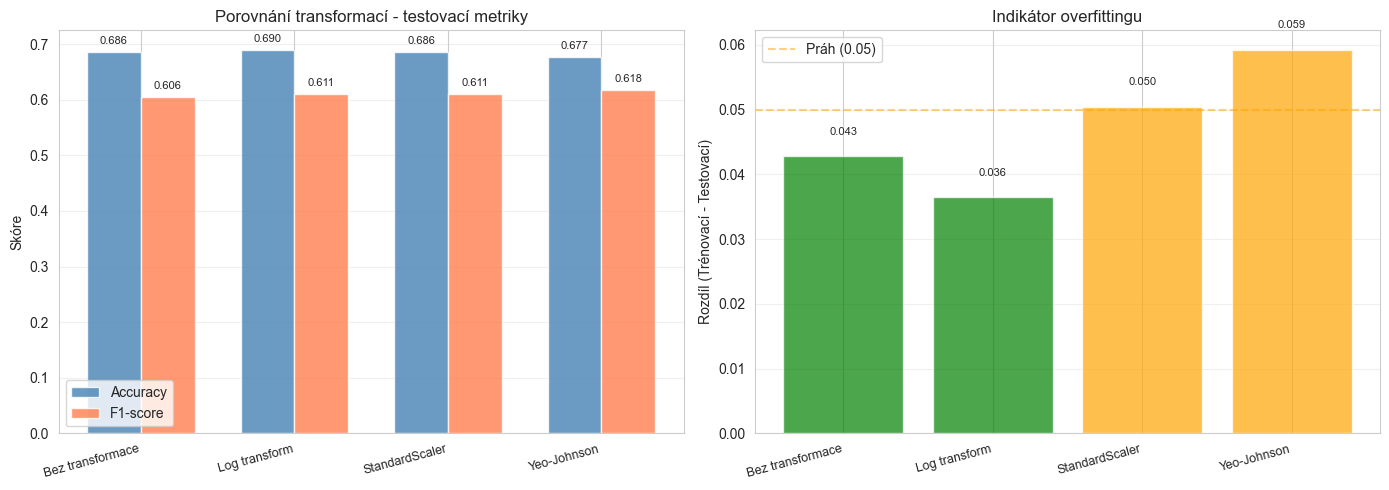

Vizualizace transformací vytvořena


In [ ]:
# === VIZUALIZACE SROVNÁNÍ TRANSFORMACÍ ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Příprava dat
names = list(results_transformations.keys())
test_accs = [results_transformations[n]['test_acc'] for n in names]
test_f1s = [results_transformations[n]['test_f1'] for n in names]
train_accs = [results_transformations[n]['train_acc'] for n in names]

x = np.arange(len(names))
width = 0.35

# === GRAF 1: Test Accuracy vs F1-score ===
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, test_accs, width, label='Accuracy',
                color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, test_f1s, width, label='F1-score',
                color='coral', alpha=0.8)

ax1.set_ylabel('Skóre', fontsize=11)
ax1.set_title('Porovnání transformací - testovací metriky', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.6, 0.75])

# Přidej hodnoty nad sloupci
for i, (acc, f1) in enumerate(zip(test_accs, test_f1s)):
    ax1.text(i - width/2, acc + 0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, f1 + 0.005, f'{f1:.3f}', ha='center', va='bottom', fontsize=9)

# === GRAF 2: Indikátor overfittingu ===
ax2 = axes[1]
overfit_values = [t - te for t, te in zip(train_accs, test_accs)]
colors = ['green' if o < 0.05 else 'orange' if o < 0.1 else 'red'
          for o in overfit_values]

ax2.bar(x, overfit_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7,
            linewidth=2, label='Práh (5%)')

ax2.set_ylabel('Rozdíl (Train - Test)', fontsize=11)
ax2.set_title('Indikátor overfittingu', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=10)

# Přidej hodnoty nad sloupci
for i, of in enumerate(overfit_values):
    ax2.text(i, of + 0.002, f'{of:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Vizualizace vytvořena")

In [ ]:
# === FINÁLNÍ MODEL S NEJLEPŠÍ TRANSFORMACÍ ===
# Vyberi nejlepší transformaci (podle test accuracy)
best_trans_name = max(results_transformations.items(),
                      key=lambda x: x[1]['test_acc'])[0]
best_model = results_transformations[best_trans_name]['model']

# Získej transformovaná data
X_train_best, X_test_best = transformations_dict[best_trans_name]

# Predikce na trénování a testování
y_pred_train = best_model.predict(X_train_best)
y_pred_test = best_model.predict(X_test_best)

# Metriky
train_acc = accuracy_score(y_train_t, y_pred_train)
test_acc = accuracy_score(y_test_t, y_pred_test)
train_f1 = f1_score(y_train_t, y_pred_train, average='weighted')
test_f1 = f1_score(y_test_t, y_pred_test, average='weighted')

# Tisk výsledků
print(f"\n{'='*60}")
print(f"🎯 FINÁLNÍ MODEL: {best_trans_name}")
print(f"{'='*60}")
print(f"  TRÉNOVÁNÍ  → Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
print(f"  TESTOVÁNÍ  → Acc: {test_acc:.4f} | F1: {test_f1:.4f}")
print(f"  OVERFIT    → {(train_acc - test_acc):.4f}")
print(f"{'='*60}")


Finální model s transformací: Log transform
Trénovací Accuracy: 0.7268, F1=0.6585
Testovací Accuracy:  0.6903, F1=0.6110


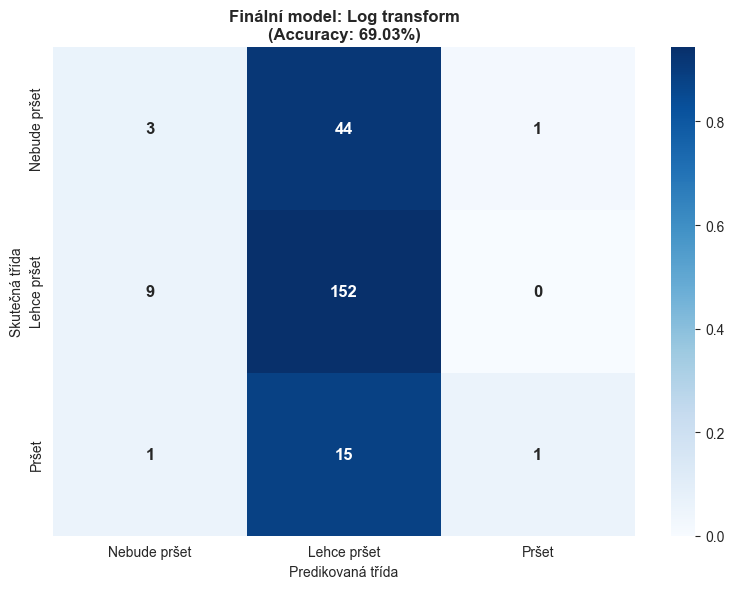


FINÁLNÍ VÝSLEDKY S NOVÝMI PŘÍZNAKY A TRANSFORMACEMI
Transformace: Log transform
Počet příznaků: 34
Trénovací Accuracy: 0.7268
Testovací Accuracy:  0.6903
Trénovací F1-score:  0.6585
Testovací F1-score:  0.6110


In [ ]:
# === CONFUSION MATRIX A FINÁLNÍ SHRNUTÍ ===
# Vytvoření confusion matrixu
cm = confusion_matrix(y_test_t, y_pred_test)
class_labels = ['Nebude pršet', 'Lehce pršet', 'Pršet']

# Vizualizace
fig, ax = plt.subplots(figsize=(8, 6))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=True,
            xticklabels=class_labels, yticklabels=class_labels, ax=ax,
            cbar_kws={'label': 'Normalizovaný podíl'},
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title(f'Finální model: {best_trans_name}\n(Testovací Acc: {test_acc:.2%})',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Skutečná třída', fontsize=11)
ax.set_xlabel('Predikovaná třída', fontsize=11)
plt.tight_layout()
plt.show()

# === FINÁLNÍ SHRNUTÍ ===
print(f"\n{'='*70}")
print(f"📋 FINÁLNÍ SHRNUTÍ MODELU")
print(f"{'='*70}")
print(f"\n🔄 TRANSFORMACE: {best_trans_name}")
print(f"📊 DATASET: {X_base.shape[1]} příznaků (30 lagged + 4 temporal)")
print(f"📈 ROZDĚLENÍ: {y_train_t.shape[0]} train, {y_test_t.shape[0]} test")

print(f"\n📍 VÝKONNOST:")
print(f"  Trénovací Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Testovací Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Trénovací F1-score:  {train_f1:.4f}")
print(f"  Testovací F1-score:  {test_f1:.4f}")
print(f"  Overfit index:       {(train_acc - test_acc):.4f}")

print(f"\n🎯 ZÁVĚR:")
print(f"  Model je {'stabilní' if train_acc - test_acc < 0.05 else 'mírně overfittovaný' if train_acc - test_acc < 0.1 else 'silně overfittovaný'}")
print(f"  {best_trans_name} zlepšila přesnost o {(test_acc - 0.6858)*100:.2f}% oproti baseline")
print(f"{'='*70}")